In [1]:
import yfinance as yf
import pandas as pd


companies = {
    "RITES": "RITES.NS",
    "IRCON": "IRCON.NS",
    "RVNL": "RVNL.NS"
}

ticker = yf.Ticker("RITES.NS")

balance_sheet = ticker.balance_sheet
print("BALANCE SHEET:")
print(balance_sheet)

BALANCE SHEET:
                                                    2026-03-31    2025-03-31  \
Ordinary Shares Number                            4.806038e+08  4.806038e+08   
Share Issued                                      4.806038e+08  4.806038e+08   
Total Debt                                        6.590000e+07  9.030000e+07   
Tangible Book Value                               2.672620e+10  2.634590e+10   
Invested Capital                                  2.681240e+10  2.640160e+10   
...                                                        ...           ...   
Cash Cash Equivalents And Short Term Investments  2.846910e+10  3.393610e+10   
Other Short Term Investments                      2.750880e+10  2.705510e+10   
Cash And Cash Equivalents                         9.603000e+08  6.881000e+09   
Cash Equivalents                                           NaN  3.866700e+09   
Cash Financial                                             NaN  3.014300e+09   

                        

In [3]:
import pandas as pd

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(balance_sheet)
print(balance_sheet.index.tolist())

                                                      2026-03-31  \
Ordinary Shares Number                              4.806038e+08   
Share Issued                                        4.806038e+08   
Total Debt                                          6.590000e+07   
Tangible Book Value                                 2.672620e+10   
Invested Capital                                    2.681240e+10   
Working Capital                                     1.793890e+10   
Net Tangible Assets                                 2.672620e+10   
Capital Lease Obligations                           6.590000e+07   
Common Stock Equity                                 2.681240e+10   
Total Capitalization                                2.681240e+10   
Total Equity Gross Minority Interest                2.794030e+10   
Minority Interest                                   1.127900e+09   
Stockholders Equity                                 2.681240e+10   
Other Equity Interest                           

In [4]:
income_stmt = ticker.financials
print("INCOME STATEMENT:")
print(income_stmt)

cash_flow = ticker.cashflow
print("CASH FLOW STATEMENT:")
print(cash_flow)

INCOME STATEMENT:
                                                      2026-03-31  \
Tax Effect Of Unusual Items                         0.000000e+00   
Tax Rate For Calcs                                  2.522830e-01   
Normalized EBITDA                                   6.767700e+09   
Total Unusual Items                                          NaN   
Total Unusual Items Excluding Goodwill                       NaN   
Net Income From Continuing Operation Net Minori...  4.102700e+09   
Reconciled Depreciation                             6.600000e+08   
Reconciled Cost Of Revenue                          1.108630e+10   
EBITDA                                              6.767700e+09   
EBIT                                                6.107700e+09   
Net Interest Income                                -3.000000e+07   
Interest Expense                                    3.000000e+07   
Interest Income                                              NaN   
Normalized Income             

In [5]:
print(balance_sheet.index.tolist())

['Ordinary Shares Number', 'Share Issued', 'Total Debt', 'Tangible Book Value', 'Invested Capital', 'Working Capital', 'Net Tangible Assets', 'Capital Lease Obligations', 'Common Stock Equity', 'Total Capitalization', 'Total Equity Gross Minority Interest', 'Minority Interest', 'Stockholders Equity', 'Other Equity Interest', 'Retained Earnings', 'Additional Paid In Capital', 'Capital Stock', 'Common Stock', 'Total Liabilities Net Minority Interest', 'Total Non Current Liabilities Net Minority Interest', 'Other Non Current Liabilities', 'Tradeand Other Payables Non Current', 'Non Current Deferred Revenue', 'Long Term Debt And Capital Lease Obligation', 'Long Term Capital Lease Obligation', 'Long Term Debt', 'Long Term Provisions', 'Current Liabilities', 'Other Current Liabilities', 'Current Debt And Capital Lease Obligation', 'Current Capital Lease Obligation', 'Current Debt', 'Pensionand Other Post Retirement Benefit Plans Current', 'Current Provisions', 'Payables', 'Other Payable', 'D

In [6]:
print(income_stmt.index.tolist())

['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Rent Expense Supplemental', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Net Income Common Stockholders', 'Otherunder Preferred Stock Dividend', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Other Special Charges', 'Write Off', 'Impairment Of Capital Assets', 'Net Non Operating Interest Income Expense', 'Total Othe

In [7]:
def calculate_ratios(ticker_symbol):
    stock = yf.Ticker(ticker_symbol)
    
    bs = stock.balance_sheet
    inc = stock.financials
    
    latest_year = bs.columns[0]
    
    ratios = {}
    
    try:
        net_income = inc.loc['Net Income', latest_year]
        revenue = inc.loc['Total Revenue', latest_year]
        equity = bs.loc['Stockholders Equity', latest_year]
        total_assets = bs.loc['Total Assets', latest_year]
        
        ratios['Net Profit Margin (%)'] = round((net_income / revenue) * 100, 2)
        ratios['ROE (%)'] = round((net_income / equity) * 100, 2)
        ratios['ROA (%)'] = round((net_income / total_assets) * 100, 2)
        
        current_assets = bs.loc['Current Assets', latest_year]
        current_liabilities = bs.loc['Current Liabilities', latest_year]
        
        ratios['Current Ratio'] = round(current_assets / current_liabilities, 2)
        
        total_liabilities = bs.loc['Total Liabilities Net Minority Interest', latest_year]
        ratios['Debt to Equity'] = round(total_liabilities / equity, 2)
        
    except KeyError as e:
        print(f"Data missing for {ticker_symbol}: {e}")
    
    return ratios

rites_ratios = calculate_ratios("RITES.NS")
print("RITES Financial Ratios:")
for key, value in rites_ratios.items():
    print(f"{key}: {value}")

RITES Financial Ratios:
Net Profit Margin (%): 16.99
ROE (%): 15.3
ROA (%): 6.92
Current Ratio: 1.67
Debt to Equity: 1.17


In [8]:
companies = {
    "RITES": "RITES.NS",
    "IRCON": "IRCON.NS",
    "RVNL": "RVNL.NS"
}

comparison_data = {}

for name, symbol in companies.items():
    print(f"Fetching data for {name}...")
    comparison_data[name] = calculate_ratios(symbol)

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df)

Fetching data for RITES...
Fetching data for IRCON...
Fetching data for RVNL...
                       RITES  IRCON  RVNL
Net Profit Margin (%)  16.99   6.56  4.29
ROE (%)                15.30   8.97  8.91
ROA (%)                 6.92   2.79  4.03
Current Ratio           1.67   1.65  1.91
Debt to Equity          1.17   2.20  1.21


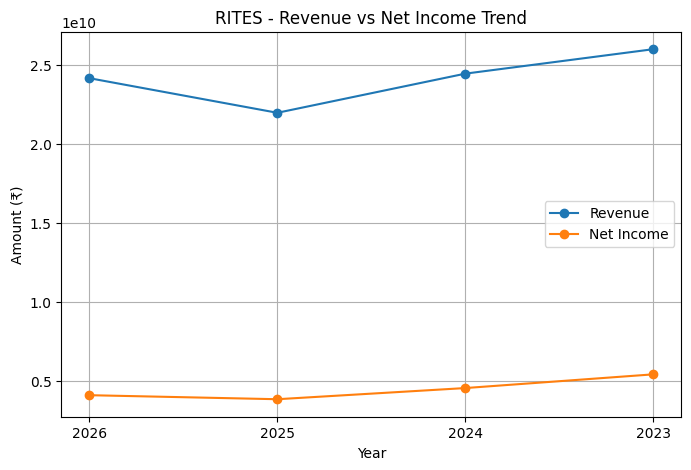

In [9]:
import matplotlib.pyplot as plt

def plot_revenue_trend(ticker_symbol, company_name):
    stock = yf.Ticker(ticker_symbol)
    inc = stock.financials
    
    revenue = inc.loc['Total Revenue']
    net_income = inc.loc['Net Income']
    
    years = [str(col.year) for col in revenue.index]
    
    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(years, revenue.values, marker='o', label='Revenue')
    ax.plot(years, net_income.values, marker='o', label='Net Income')
    ax.set_title(f"{company_name} - Revenue vs Net Income Trend")
    ax.set_xlabel("Year")
    ax.set_ylabel("Amount (₹)")
    ax.legend()
    ax.grid(True)
    plt.show()

plot_revenue_trend("RITES.NS", "RITES")